In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('customers_clean.csv')
df['invoicedate'] = pd.to_datetime(df['invoicedate'])

In [3]:
max_date = df['invoicedate'].max()
cutoff   = max_date - pd.Timedelta(days=90)

In [4]:
df_pre  = df[df['invoicedate'] < cutoff].copy()
df_post = df[df['invoicedate'] >= cutoff].copy()

In [5]:
snapshot_date = cutoff

rfm = df_pre.groupby('customerid').agg(
    recency   = ('invoicedate', lambda x: (snapshot_date - x.max()).days),
    frequency = ('invoiceno', 'nunique'),
    monetary  = ('total_price', 'sum')
).reset_index()

In [6]:
pre_cutoff  = df_pre['customerid'].unique()
post_cutoff = df_post['customerid'].unique()

churn_df = pd.DataFrame({'customerid': pre_cutoff})
churn_df['churned'] = churn_df['customerid'].apply(
    lambda x: 0 if x in post_cutoff else 1
)

In [7]:
model_df = rfm.merge(churn_df, on='customerid', how='inner')

In [8]:
model_df.isnull().sum()

customerid    0
recency       0
frequency     0
monetary      0
churned       0
dtype: int64

In [9]:
model_df['recency_log']   = np.log1p(model_df['recency'])
model_df['frequency_log'] = np.log1p(model_df['frequency'])
model_df['monetary_log']  = np.log1p(model_df['monetary'])

In [10]:
features = ['recency_log', 'frequency_log', 'monetary_log']

X = model_df[features]
y = model_df['churned']

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

In [13]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    random_state=42,
    eval_metric='logloss'
)

model.fit(X_train, y_train,
          eval_set=[(X_test, y_test)],
          verbose=False)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [14]:
from sklearn.metrics import classification_report, roc_auc_score, RocCurveDisplay

y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print('ROC-AUC:', roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.68      0.69      0.69       260
           1       0.59      0.58      0.58       196

    accuracy                           0.64       456
   macro avg       0.63      0.63      0.63       456
weighted avg       0.64      0.64      0.64       456

ROC-AUC: 0.7076040031397175


In [15]:
# RFM Scores using quintiles
model_df['r_score'] = pd.qcut(model_df['recency'], q=5, labels=[5,4,3,2,1])    # lower recency = better
model_df['f_score'] = pd.qcut(model_df['frequency'].rank(method='first'), q=5, labels=[1,2,3,4,5])
model_df['m_score'] = pd.qcut(model_df['monetary'].rank(method='first'), q=5, labels=[1,2,3,4,5])

# Combined RFM score
model_df['rfm_score'] = (model_df['r_score'].astype(int) + 
                         model_df['f_score'].astype(int) + 
                         model_df['m_score'].astype(int))

In [16]:
features = [
    'recency_log', 'frequency_log', 'monetary_log',  # continuous
    'r_score', 'f_score', 'm_score', 'rfm_score'     # binned scores
]

X = model_df[features].astype(float)
y = model_df['churned']

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

In [18]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=42,
    eval_metric='logloss'
)

model.fit(X_train, y_train,
          eval_set=[(X_test, y_test)],
          verbose=False)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [19]:
y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print('ROC-AUC:', roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.70      0.70      0.70       260
           1       0.60      0.61      0.61       196

    accuracy                           0.66       456
   macro avg       0.65      0.65      0.65       456
weighted avg       0.66      0.66      0.66       456

ROC-AUC: 0.7076923076923076


In [20]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [25]:
y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print('ROC-AUC:', roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.69      0.75      0.72       260
           1       0.63      0.55      0.58       196

    accuracy                           0.66       456
   macro avg       0.66      0.65      0.65       456
weighted avg       0.66      0.66      0.66       456

ROC-AUC: 0.7130788854003139


In [27]:
model_df['churn_probability'] = model.predict_proba(X)[:, 1]

monetary_threshold = model_df['monetary'].median()
churn_threshold    = 0.5

def assign_intervention(row):
    high_churn = row['churn_probability'] >= churn_threshold
    high_value = row['monetary'] >= monetary_threshold

    if high_churn and high_value:
        return 'Save'
    elif high_churn and not high_value:
        return 'Lost Cause'
    elif not high_churn and high_value:
        return 'Protect'
    else:
        return 'Maintain'

model_df['intervention'] = model_df.apply(assign_intervention, axis=1)

<Axes: ylabel='intervention'>

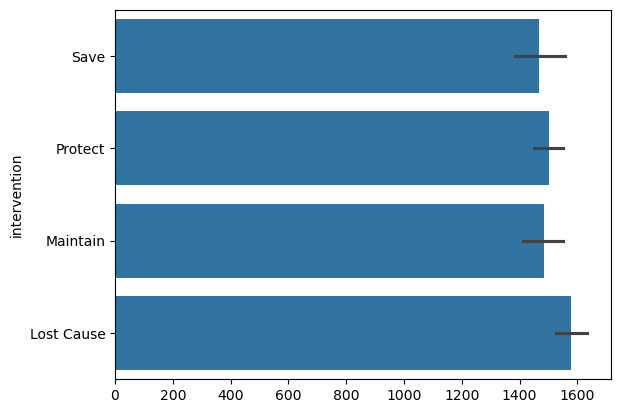

In [32]:
sns.barplot(model_df.intervention, )

In [34]:
import joblib

joblib.dump(model, 'churn_model.pkl')

['churn_model.pkl']